In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

from functools import partial

import numpy as onp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from msmjax.benchmark_tools import (
    path_input_structures,
    evaluate_structure_with_lammps_p3m,
)
from msmjax.convenience import (
    suggest_msm_params,
    set_up_kernel_fns,
)
from msmjax.core.shortrange import make_pair_term_fn, make_compute_U0
from msmjax.flexcell import make_flex_cell_U1plus_fn

# Load structure

In [2]:
structures = onp.load(path_input_structures / "structures_1000.npz")

i_structure = 0
pos = structures["positions"][i_structure].astype(onp.float64)
chg = structures["charges"][i_structure].astype(onp.float64)
cell = structures["cells"][i_structure].astype(onp.float64)

box_lengths = onp.diag(cell)
n_structures = len(structures["positions"])
n_particles = pos.shape[0]
avg_particle_spacing = (onp.linalg.det(cell) / n_particles) ** (1 / 3)

# Definitions

## Energy calculators

In [3]:
calc_energy_ref_nonperiodic = make_pair_term_fn(
    kernel_fn=lambda x: 1.0 / x, pbc=(False, False, False)
)


@jax.jit
def calc_e_and_f_ref_np(positions, charges, cell):
    # TODO: name; move up to where the other function definitions are
    value, grad = jax.value_and_grad(calc_energy_ref_nonperiodic)(
        positions, charges, cell=onp.eye(3)
    )
    return value, -grad


calc_e_and_f_ref_periodic = partial(
    evaluate_structure_with_lammps_p3m,
    lammps_executable="/home/florian/Downloads/lammps-static/bin/lmp",
    max_neighbors_one_atom=10000,
)


def calc_ref_results_set_of_structures(
    set_of_positions, set_of_charges, set_of_cells
):
    energies_ref_nonperiodic, forces_ref_nonperiodic = (
        evaluate_set_of_structures(
            calc_e_and_f_ref_np, set_of_positions, set_of_charges, set_of_cells
        )
    )
    energies_ref_periodic, forces_ref_periodic = evaluate_set_of_structures(
        calc_e_and_f_ref_periodic,
        set_of_positions,
        set_of_charges,
        set_of_cells,
    )
    results = {
        "pbc-False": {
            "energies": energies_ref_nonperiodic,
            "forces": forces_ref_nonperiodic,
        },
        "pbc-True": {
            "energies": energies_ref_periodic,
            "forces": forces_ref_periodic,
        },
    }

    return results

In [4]:
def set_up_flex_cell_msm(
    reference_cell, pbc, cell_mode, supercell_diag, **msm_params
):
    kernel_fns = set_up_kernel_fns(**msm_params)
    calc_U0 = make_compute_U0(
        kernel_fns=kernel_fns, pbc=pbc, supercell_diag=supercell_diag
    )
    calc_U1plus = make_flex_cell_U1plus_fn(
        kernel_fns=kernel_fns,
        pbc=pbc,
        reference_cell=reference_cell,
        cell_mode=cell_mode,
        **msm_params,
    )

    def calc_energy(positions, charges, cell):
        return calc_U0(positions, charges, cell) + calc_U1plus(
            positions, charges, cell
        )

    @jax.jit
    def calc_energy_and_forces(positions, charges, cell):
        value, grad = jax.value_and_grad(calc_energy)(positions, charges, cell)
        return value, -grad

    return calc_energy_and_forces

In [5]:
def set_up_flex_cell_long_range_only(
    reference_cell, pbc, cell_mode, **msm_params
):
    kernel_fns = set_up_kernel_fns(**msm_params)
    calc_U1plus_direct, calc_f1plus_via_potential, _ = (
        make_flex_cell_U1plus_fn(
            kernel_fns=kernel_fns,
            pbc=pbc,
            reference_cell=reference_cell,
            cell_mode=cell_mode,
            forces=True,
            **msm_params,
        )
    )

    def calc_f1plus_grad_direct(positions, charges, cell):
        return -jax.grad(calc_U1plus_direct)(positions, charges, cell)

    return (
        calc_U1plus_direct,
        calc_f1plus_grad_direct,
        calc_f1plus_via_potential,
    )

## Other helper functions

In [6]:
def evaluate_set_of_structures(
    energy_and_forces_fn, set_of_positions, set_of_charges, set_of_cells
):
    energies = onp.full(len(all_positions), onp.nan, dtype=float)
    forces = onp.full_like(onp.asarray(set_of_positions), onp.nan)
    for i, (pos, chg, cell) in enumerate(
        zip(set_of_positions, set_of_charges, set_of_cells)
    ):
        try:
            e, f = energy_and_forces_fn(pos, chg, cell)
            energies[i] = e
            forces[i] = f
        except Exception as exc:
            print(repr(exc))
            continue

    return energies, forces


# TODO: name
def run_and_compare_msm_for_set_of_structures(
    energy_and_forces_fn,
    set_of_positions,
    set_of_charges,
    set_of_cells,
    reference_forces,
):
    energies, forces = evaluate_set_of_structures(
        energy_and_forces_fn, set_of_positions, set_of_charges, set_of_cells
    )
    force_rmses = [
        calc_relative_rmse_percent(y_pred=f, y_true=f_ref)
        for f, f_ref in zip(forces, reference_forces)
    ]

    return {"energies": energies, "forces": forces, "force_rmses": force_rmses}

In [7]:
def calc_rmse(y_pred, y_true):
    return onp.sqrt(((y_pred - y_true) ** 2).mean())


def calc_relative_rmse_percent(y_pred, y_true):
    return calc_rmse(y_pred, y_true) / y_true.std() * 100

In [8]:
def get_min_cutoff_across_structures(set_of_cells):
    return min([get_max_cutoff_3d(cl) for cl in set_of_cells])

In [9]:
def get_max_stencil_size(set_of_cells, n_gridpoints, cutoff):
    all_stencil_sizes = []
    for cl in set_of_cells:
        # TODO: This determination of spacing is incorrect for nonperiodic cases
        #  Should be done somehow directly based on spacing, not n_gridpoints
        deformed_spacings = onp.linalg.norm(cl, axis=1) / n_gridpoints
        stencil_size = determine_min_kernel_stencil_size(
            cell=cl, spacings=deformed_spacings, cutoff=cutoff, padding=0
        )
        all_stencil_sizes.append(stencil_size)
    all_stencil_sizes = onp.array(all_stencil_sizes)
    return onp.max(all_stencil_sizes, axis=0)


def get_stencil_padding(reference_cell, set_of_cells, n_gridpoints, cutoff):
    ref_stencil_size = determine_min_kernel_stencil_size(
        cell=reference_cell,
        spacings=onp.linalg.norm(reference_cell, axis=1) / n_gridpoints,
        cutoff=cutoff,
        padding=0,
    )
    max_stencil_size = get_max_stencil_size(set_of_cells, n_gridpoints, cutoff)
    return max_stencil_size - ref_stencil_size

In [10]:
# single_grid_cell = (
#     cell
#     / onp.linalg.norm(cell, axis=1)[:, onp.newaxis]
#     * onp.atleast_1d(actual_spacing)[:, onp.newaxis]
# )
# single_grid_cell

In [11]:
# spacings_unit_cube = onp.diag(single_grid_cell @ onp.linalg.pinv(cell))
# spacings_unit_cube

In [12]:
# cell * spacings_unit_cube[:, onp.newaxis]

In [13]:
# arr * onp.array([1, 2, 3])[:, onp.newaxis]

In [14]:
# arr = onp.arange(9).reshape((3, 3))
# arr

In [15]:
# arr_unit = arr / onp.linalg.norm(arr, axis=1)[:, onp.newaxis]
# arr_unit

In [16]:
# onp.linalg.norm(arr_unit, axis=1)

## Plot setings

In [17]:
FIGSIZE = (8, 5)
PLOT_TITLES = {
    "pbc-False": "Non-periodic: flexible-cell MSM vs. reference\n(explicit all-pairs summation)",
    "pbc-True": "Periodic: flexible-cell MSM vs. reference\n(LAMMPS with 'pair_style coul/long 10.0', 'kspace_style pppm 1e-5')",
}

# Orthogonal: Isotropic strain

In [18]:
# Create deformed structures
lower = 0.5
upper = 2.0
stepsize = 0.05
n_steps = int(onp.round((1.4 - 0.6) / 0.05))
all_deformations = onp.linspace(lower, upper, n_steps)
all_positions = [pos * deformation for deformation in all_deformations]
all_charges = [chg] * len(all_positions)
all_cells = [cell * deformation for deformation in all_deformations]

# MSM parameters
CELL_MODE = "ortho"
R_CUT = 3.5
SPACINGS = [1.0, 0.8, 0.6]
SUPERCELL_DIAG = (2, 2, 2)

# Check that cutoff fits for all trial structures
all_super_cells = [
    cl * onp.array(SUPERCELL_DIAG)[:, onp.newaxis] for cl in all_cells
]
assert get_min_cutoff_across_structures(all_super_cells) >= R_CUT

# Run reference calculations
results_ref = calc_ref_results_set_of_structures(
    all_positions, all_charges, all_cells
)

# Run and compare MSM calculations
results_msm_flex = {}
for pbc_key, pbc in zip(
    ["pbc-False", "pbc-True"], [(False, False, False), (True, True, True)]
):
    results_msm_flex[pbc_key] = {}
    for spacing in SPACINGS:
        msm_params = suggest_msm_params(
            box_lengths=box_lengths,
            pbc=pbc,
            n_particles=n_particles,
            level_one_gridspacing=spacing * avg_particle_spacing,
            level_zero_cutoff=R_CUT * avg_particle_spacing,
        )
        # TODO: supercell_diag required for the more deformed structures?
        calc_e_and_f_msm = set_up_flex_cell_msm(
            reference_cell=cell,
            pbc=pbc,
            supercell_diag=onp.where(pbc, SUPERCELL_DIAG, 1),
            cell_mode=CELL_MODE,
            **msm_params,
        )
        actual_spacings = msm_params["level_one_gridspacing"]
        results_msm_flex[pbc_key][actual_spacings[0]] = (
            run_and_compare_msm_for_set_of_structures(
                energy_and_forces_fn=calc_e_and_f_msm,
                set_of_positions=all_positions,
                set_of_charges=all_charges,
                set_of_cells=all_cells,
                reference_forces=results_ref[pbc_key]["forces"],
            )
        )

ValueError('EOF reached without finding energy')
ValueError('EOF reached without finding energy')
ValueError('EOF reached without finding energy')
ValueError('EOF reached without finding energy')
Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")



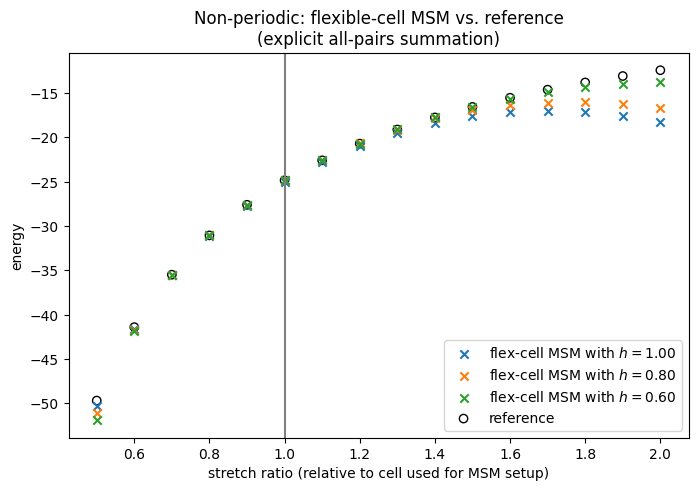

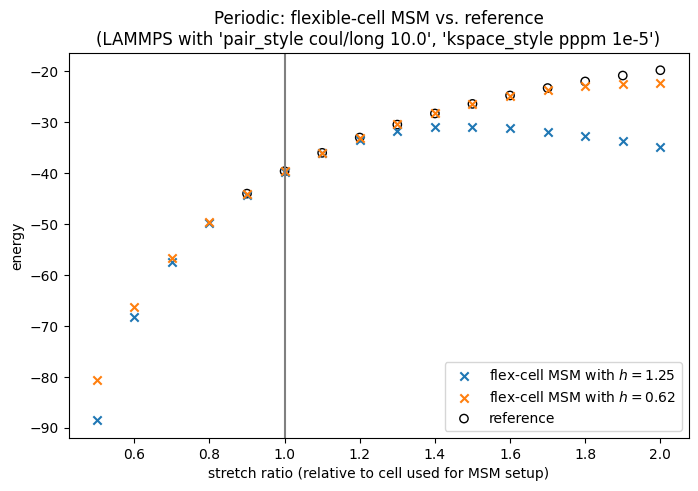

In [19]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_title(PLOT_TITLES[key_pbcs])
    ax.set_xlabel("stretch ratio (relative to cell used for MSM setup)")
    ax.set_ylabel("energy")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            all_deformations,
            res["energies"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.scatter(
        all_deformations,
        results_ref[key_pbcs]["energies"],
        color="black",
        facecolor="none",
        label="reference",
        zorder=-10,
    )
    ax.axvline(1.0, color="gray")
    ax.legend()
    # fig.savefig(f"energies_{key_pbcs}.pdf")
    plt.show()

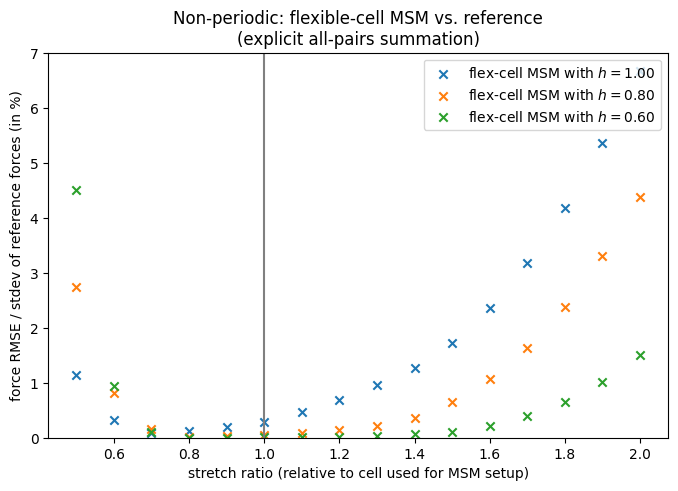

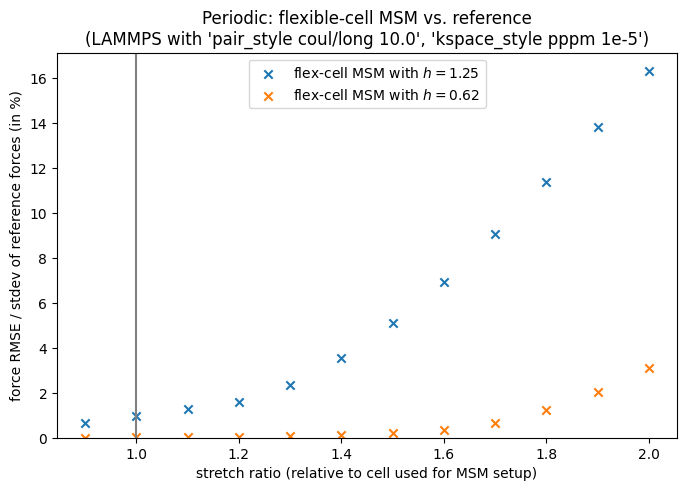

In [20]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_title(PLOT_TITLES[key_pbcs])
    ax.set_xlabel("stretch ratio (relative to cell used for MSM setup)")
    ax.set_ylabel("force RMSE / stdev of reference forces (in %)")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            all_deformations,
            res["force_rmses"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.set_ylim([0, ax.get_ylim()[1]])
    ax.axvline(1.0, color="gray")
    ax.legend()
    # fig.savefig(f"force_rsmes_{key_pbcs}.pdf")
    plt.show()

# Orthogonal: Strain along one axis

In [21]:
# Create deformed structures
lower = 0.5
upper = 2.0
stepsize = 0.05
n_steps = int(onp.round((1.4 - 0.6) / 0.05))
all_deformations = onp.linspace(lower, upper, n_steps)
all_positions = [pos * [1, 1, deformation] for deformation in all_deformations]
all_charges = [chg] * len(all_positions)
all_cells = [cell * [1, 1, deformation] for deformation in all_deformations]

# MSM parameters
CELL_MODE = "ortho"
R_CUT = 3.5
SPACINGS = [1.0, 0.8, 0.6]
SUPERCELL_DIAG = (1, 1, 2)

# Check that cutoff fits for all trial structures
all_super_cells = [
    cl * onp.array(SUPERCELL_DIAG)[:, onp.newaxis] for cl in all_cells
]
assert get_min_cutoff_across_structures(all_super_cells) >= R_CUT

# Run reference calculations
results_ref = calc_ref_results_set_of_structures(
    all_positions, all_charges, all_cells
)

# Run and compare MSM calculations
results_msm_flex = {}
for pbc_key, pbc in zip(
    ["pbc-False", "pbc-True"], [(False, False, False), (True, True, True)]
):
    results_msm_flex[pbc_key] = {}
    for spacing in SPACINGS:
        msm_params = suggest_msm_params(
            box_lengths=box_lengths,
            pbc=pbc,
            n_particles=n_particles,
            level_one_gridspacing=spacing * avg_particle_spacing,
            level_zero_cutoff=R_CUT * avg_particle_spacing,
        )
        # TODO: supercell_diag required for the more deformed structures?
        calc_e_and_f_msm = set_up_flex_cell_msm(
            reference_cell=cell,
            pbc=pbc,
            supercell_diag=onp.where(pbc, SUPERCELL_DIAG, 1),
            cell_mode=CELL_MODE,
            **msm_params,
        )
        actual_spacings = msm_params["level_one_gridspacing"]
        results_msm_flex[pbc_key][actual_spacings[0]] = (
            run_and_compare_msm_for_set_of_structures(
                energy_and_forces_fn=calc_e_and_f_msm,
                set_of_positions=all_positions,
                set_of_charges=all_charges,
                set_of_cells=all_cells,
                reference_forces=results_ref[pbc_key]["forces"],
            )
        )

ValueError('EOF reached without finding energy')
Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")



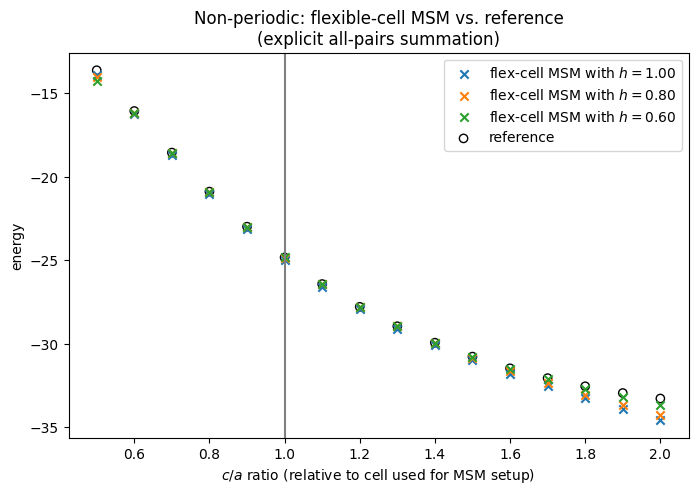

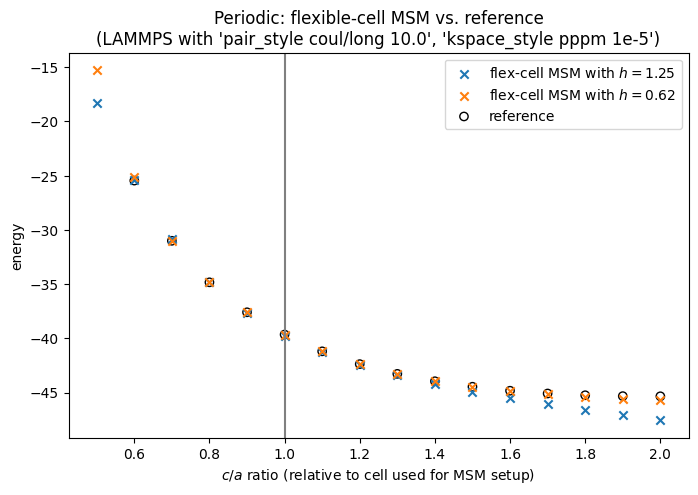

In [22]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_title(PLOT_TITLES[key_pbcs])
    ax.set_xlabel("$c/a$ ratio (relative to cell used for MSM setup)")
    ax.set_ylabel("energy")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            all_deformations,
            res["energies"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.scatter(
        all_deformations,
        results_ref[key_pbcs]["energies"],
        color="black",
        facecolor="none",
        label="reference",
        zorder=-10,
    )
    ax.axvline(1.0, color="gray")
    ax.legend()
    # fig.savefig(f"energies_{key_pbcs}.pdf")
    plt.show()

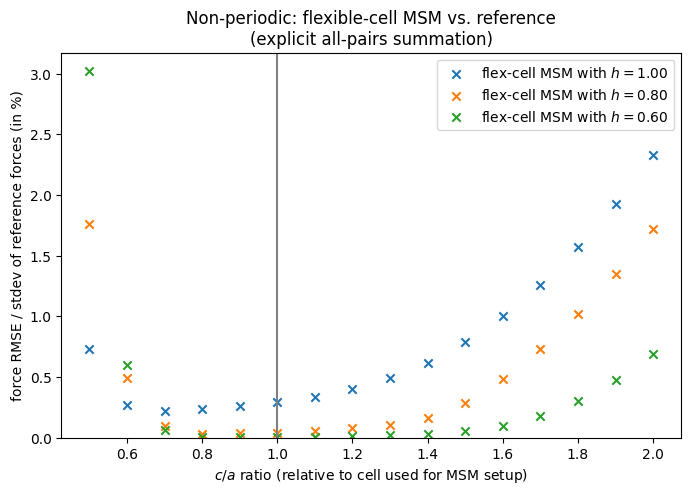

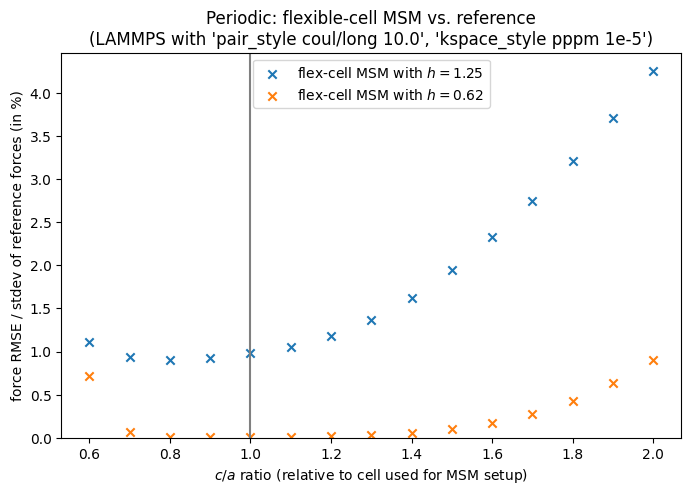

In [23]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_title(PLOT_TITLES[key_pbcs])
    ax.set_xlabel("$c/a$ ratio (relative to cell used for MSM setup)")
    ax.set_ylabel("force RMSE / stdev of reference forces (in %)")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            all_deformations,
            res["force_rmses"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.set_ylim([0, ax.get_ylim()[1]])
    ax.axvline(1.0, color="gray")
    ax.legend()
    # fig.savefig(f"force_rsmes_{key_pbcs}.pdf")
    plt.show()

# General parallelepipeds

In [24]:
from ase.atoms import Atoms
from ase.visualize import view

In [25]:
atoms = Atoms(positions=pos, charges=chg, cell=cell)
cellpar = atoms.cell.cellpar()


def make_deformed_structure(c_a_ratio=None, alpha=None, gamma=None):
    cellpar_deformed = cellpar.copy()
    if c_a_ratio is not None:
        cellpar_deformed[2] *= c_a_ratio
    if alpha is not None:
        cellpar_deformed[3] = alpha
    if gamma is not None:
        cellpar_deformed[5] = gamma
    atoms_deformed = atoms.copy()
    atoms_deformed.set_cell(cellpar_deformed, scale_atoms=True)
    pos_deformed = atoms_deformed.get_positions()
    cell_deformed = atoms_deformed.get_cell()[...]

    return pos_deformed, cell_deformed

In [26]:
# Create deformed structures
c_a_ratio = 1.0
all_gammas = onp.arange(90, 40, -5).astype(float)
all_positions = []
all_cells = []
for gamma in all_gammas:
    pos_deformed, cell_deformed = make_deformed_structure(
        gamma=gamma, c_a_ratio=c_a_ratio
    )
    all_positions.append(pos_deformed)
    all_cells.append(cell_deformed)
all_charges = [chg] * len(all_positions)

# MSM parameters
CELL_MODE = "general"
R_CUT = 3.5
SPACINGS = [1.0, 0.8, 0.6]

# Run reference calculations
results_ref = calc_ref_results_set_of_structures(
    all_positions, all_charges, all_cells
)

# Run and compare MSM calculations
results_msm_flex = {}
for pbc_key, pbc in zip(
    ["pbc-False", "pbc-True"], [(False, False, False), (True, True, True)]
):
    results_msm_flex[pbc_key] = {}
    for spacing in SPACINGS:
        msm_params = suggest_msm_params(
            box_lengths=box_lengths,
            pbc=pbc,
            n_particles=n_particles,
            level_one_gridspacing=spacing * avg_particle_spacing,
            level_zero_cutoff=R_CUT * avg_particle_spacing,
        )
        # TODO: stencil padding?
        # TODO: supercell_diag required for the more deformed structures?
        calc_e_and_f_msm = set_up_flex_cell_msm(
            reference_cell=cell,
            pbc=pbc,
            cell_mode=CELL_MODE,
            supercell_diag=1,  # TODO
            **msm_params,
        )
        actual_spacings = msm_params["level_one_gridspacing"]
        results_msm_flex[pbc_key][actual_spacings[0]] = (
            run_and_compare_msm_for_set_of_structures(
                energy_and_forces_fn=calc_e_and_f_msm,
                set_of_positions=all_positions,
                set_of_charges=all_charges,
                set_of_cells=all_cells,
                reference_forces=results_ref[pbc_key]["forces"],
            )
        )

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")



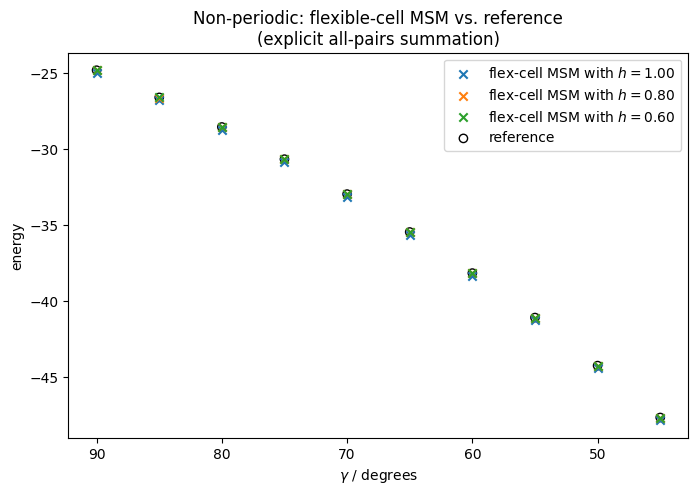

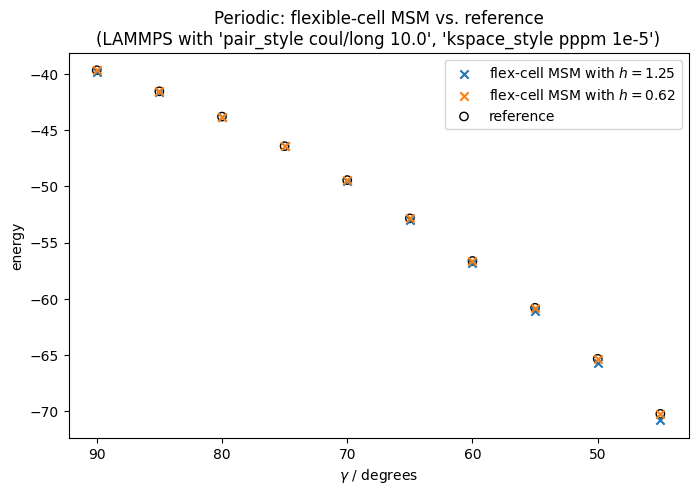

In [27]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_title(PLOT_TITLES[key_pbcs])
    # TODO: axis label
    ax.set_xlabel("$\gamma$ / degrees")
    ax.set_ylabel("energy")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            # all_deformations, # TODO
            all_gammas,
            res["energies"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.scatter(
        # all_deformations, # TODO
        all_gammas,
        results_ref[key_pbcs]["energies"],
        color="black",
        facecolor="none",
        label="reference",
        zorder=-10,
    )
    ax.invert_xaxis()
    # ax.axvline(1.0, color="gray")
    ax.legend()
    # fig.savefig(f"energies_{key_pbcs}.pdf")
    plt.show()

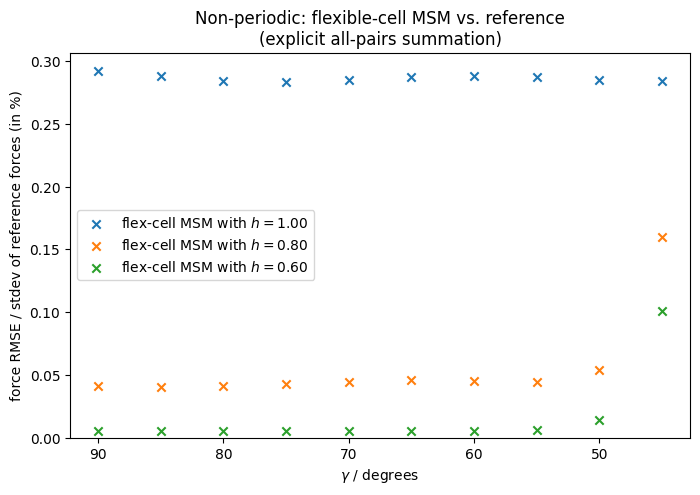

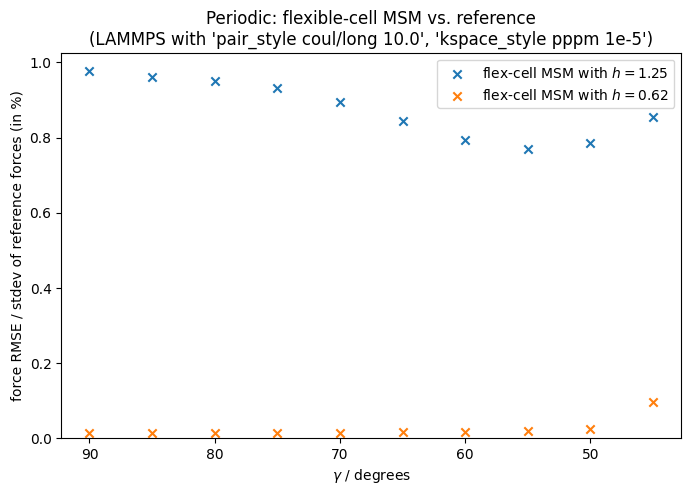

In [28]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_title(PLOT_TITLES[key_pbcs])
    ax.set_xlabel("$\gamma$ / degrees")
    ax.set_ylabel("force RMSE / stdev of reference forces (in %)")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            # all_deformations,   # TODO
            all_gammas,
            res["force_rmses"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.set_ylim([0, ax.get_ylim()[1]])
    # ax.axvline(1.0, color="gray")
    ax.invert_xaxis()
    ax.legend()
    # fig.savefig(f"force_rsmes_{key_pbcs}.pdf")
    plt.show()

In [29]:
view(Atoms(positions=pos_deformed, cell=cell_deformed))

In [30]:
from msmjax.utils import get_max_cutoff_3d
from msmjax.kernels import determine_min_kernel_stencil_size

In [31]:
get_max_cutoff_3d(cell_deformed)

Array(3.53553391, dtype=float64)

In [32]:
stencil_size_ref_config = determine_min_kernel_stencil_size(
    cell=cell, spacings=actual_spacings, cutoff=R_CUT
)
stencil_size_ref_config

(5, 5, 5)

In [33]:
# TODO: this will give incorrect number of grid points for nonperiodic
n_gridpoints = (onp.diag(cell) / actual_spacings).astype(int)
deformed_spacings = onp.linalg.norm(cell_deformed, axis=1) / n_gridpoints
stencil_size_deformed = determine_min_kernel_stencil_size(
    cell=cell_deformed, spacings=deformed_spacings, cutoff=R_CUT
)
stencil_size_deformed

(7, 7, 5)

In [34]:
onp.array(
    [
        determine_min_kernel_stencil_size(
            cell=cl, spacings=deformed_spacings, cutoff=R_CUT
        )
        for cl in all_cells
    ]
).max(axis=0)

array([7, 7, 5])

In [35]:
def get_max_stencil_size(set_of_cells, n_gridpoints, cutoff):
    all_stencil_sizes = []
    for cl in set_of_cells:
        deformed_spacings = onp.linalg.norm(cl, axis=1) / n_gridpoints
        stencil_size = determine_min_kernel_stencil_size(
            cell=cl, spacings=deformed_spacings, cutoff=cutoff
        )
        all_stencil_sizes.append(stencil_size)
    all_stencil_sizes = onp.array(all_stencil_sizes)
    return onp.max(all_stencil_sizes, axis=0)


def get_stencil_padding(reference_cell, set_of_cells, n_gridpoints, cutoff):
    ref_stencil_size = determine_min_kernel_stencil_size(
        cell=reference_cell,
        spacings=onp.linalg.norm(reference_cell, axis=1) / n_gridpoints,
        cutoff=cutoff,
    )
    max_stencil_size = get_max_stencil_size(set_of_cells, n_gridpoints, cutoff)
    return max_stencil_size - ref_stencil_size

In [36]:
max_stencil_size = get_max_stencil_size(all_cells, n_gridpoints, R_CUT)

In [37]:
stencil_padding = max_stencil_size - stencil_size_ref_config

In [38]:
stencil_padding

array([2, 2, 0])

In [39]:
get_stencil_padding(
    reference_cell=cell,
    set_of_cells=all_cells,
    n_gridpoints=n_gridpoints,
    cutoff=R_CUT,
)

array([2, 2, 0])

In [40]:
min([get_max_cutoff_3d(cl) for cl in all_cells])

Array(3.53553391, dtype=float64)

In [41]:
def get_min_cutoff_across_structures(set_of_cells):
    return min([get_max_cutoff_3d(cl) for cl in set_of_cells])

# Experiment: determine stencils for general parallelepipeds

In [41]:
import numpy.linalg as la

In [42]:
CUTOFF = 2.5
# LOWER_STRETCH_LIM = 1.2
STENCIL_PADDING = 1


def get_angle_between_vectors(v1, v2):
    return onp.arccos(onp.dot(v1, v2) / (la.norm(v1) * la.norm(v2)))

In [43]:
vec_a = onp.array([10, 0])
a = onp.linalg.norm(vec_a)
grid_angle = onp.deg2rad(60)
vec_b = a * onp.array([onp.cos(grid_angle), onp.sin(grid_angle)])

In [44]:
n_points_a = 11
n_points_b = 15

n_points_along_axes = onp.array([n_points_a, n_points_b])

grid_points_unitcube = onp.stack(
    onp.meshgrid(
        onp.linspace(0, 1, n_points_a),
        onp.linspace(0, 1, n_points_b),
        indexing="ij",
    ),
    axis=-1,
)
grid_points = grid_points_unitcube @ onp.array([vec_a, vec_b])

inds_center = n_points_along_axes // 2
# center = onp.array(
#     [
#         grid_points[n_points_a // 2, n_points_a // 2, 0],
#         grid_points[n_points_b // 2, n_points_b // 2, 1],
#     ]
# )
center = grid_points[inds_center[0], inds_center[1]]

In [45]:
phis = onp.linspace(0, 2 * onp.pi, 500)
circle_points = (CUTOFF * onp.array([onp.cos(phis), onp.sin(phis)])).T + center

inverse = la.pinv([vec_a, vec_b])

circle_points_transformed = circle_points @ inverse

half_extents = (
    circle_points_transformed.max(axis=0)
    - circle_points_transformed.min(axis=0)
) / 2

# TODO: use correct spacings if periodic
spacings_transformed = 1 / (n_points_along_axes - 1)

# TODO: ceil?
sizes_from_center = onp.floor(half_extents / spacings_transformed).astype(int)
sizes_from_center += onp.asarray(STENCIL_PADDING)

included_inds_along_axes = [
    i + onp.arange(-s, s + 1) for i, s in zip(inds_center, sizes_from_center)
]
included_inds = tuple(
    i.ravel() for i in (onp.meshgrid(*included_inds_along_axes, indexing="ij"))
)

grid_points[included_inds].shape

(77, 2)

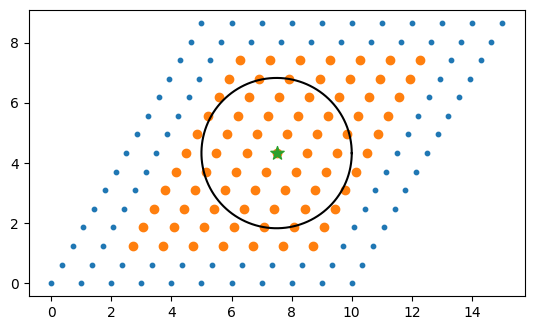

In [46]:
grid_points_to_plot = grid_points
center_to_plot = center
circle_points_to_plot = circle_points

fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.scatter(grid_points_to_plot[..., 0], grid_points_to_plot[..., 1], s=10)
ax.scatter(
    grid_points_to_plot[included_inds][:, 0],
    grid_points_to_plot[included_inds][:, 1],
)
ax.scatter(*center_to_plot, marker="*", s=100)
ax.plot(
    circle_points_to_plot[:, 0], circle_points_to_plot[:, 1], color="black"
)

plt.show()

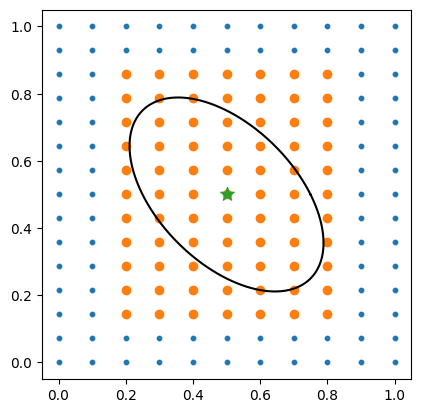

In [47]:
grid_points_to_plot = grid_points @ inverse
center_to_plot = center @ inverse
circle_points_to_plot = circle_points @ inverse

fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.scatter(grid_points_to_plot[..., 0], grid_points_to_plot[..., 1], s=10)
ax.scatter(
    grid_points_to_plot[included_inds][:, 0],
    grid_points_to_plot[included_inds][:, 1],
)
ax.scatter(*center_to_plot, marker="*", s=100)
ax.plot(
    circle_points_to_plot[:, 0], circle_points_to_plot[:, 1], color="black"
)

plt.show()

In [48]:
spacings = la.norm(onp.array([vec_a, vec_b]), axis=1) / (
    n_points_along_axes - 1
)

In [49]:
spacings

array([1.        , 0.71428571])

In [50]:
inverse @ spacings

array([0.1       , 0.02474358])

In [51]:
spacings @ inverse

array([0.0587607 , 0.08247861])

In [52]:
1 / (n_points_along_axes - 1)

array([0.1       , 0.07142857])

In [53]:
(vec_a / (n_points_a - 1)) @ inverse

array([ 1.00000000e-01, -2.08166817e-17])

In [54]:
(vec_b / (n_points_a - 1)) @ inverse

array([6.9388939e-18, 1.0000000e-01])

In [55]:
cell = onp.array([vec_a, vec_b])

In [56]:
cell / la.norm(cell, axis=1)

array([[1.       , 0.       ],
       [0.5      , 0.8660254]])

In [57]:
one_grid_cell = cell / la.norm(cell, axis=1) * spacings[:, onp.newaxis]

In [58]:
onp.diag(one_grid_cell @ inverse)

array([0.1       , 0.07142857])

## With function

In [59]:
from msmjax.flexcell import determine_min_kernel_stencil_size

In [60]:
cell = structures["cells"][0].astype(onp.float64)

In [61]:
spacing = 1.0
cutoff = 2.5

In [62]:
determine_min_kernel_stencil_size(
    cell=cell, spacings=spacing, cutoff=2 * cutoff, padding=[1, 1, 1]
)

(6, 6, 6)

In [63]:
(2 * cutoff) / spacing

5.0

In [64]:
s = 0

In [65]:
onp.arange(-s, s + 1)

array([0])

In [66]:
tuple([157])

(157,)

In [67]:
jax.scipy.signal.convolve(onp.arange(4), onp.arange(-2, 3))

Array([ 0., -2., -5., -8., -2.,  4.,  7.,  6.], dtype=float64)

# Experiment: performance

In [68]:
# TODO: Why is this so slow? Related to the general inefficiency of the current short-range implementation?
test_fn = calc_e_and_f_ref_np

test_fn(pos, chg, cell)[0].block_until_ready()
%timeit test_fn(pos, chg, cell)[1].block_until_ready()

5.18 ms ± 310 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [69]:
# TODO: Why is this so slow? Related to the general inefficiency of the current short-range implementation?
test_fn = jax.jit(jax.grad(calc_energy_ref_nonperiodic))

test_fn(pos, chg, cell).block_until_ready()
%timeit test_fn(pos, chg, cell).block_until_ready()

8.51 ms ± 130 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [70]:
test_fn = jax.jit(calc_energy_ref_nonperiodic)

test_fn(pos, chg, cell).block_until_ready()
%timeit test_fn(pos, chg, cell).block_until_ready()

275 µs ± 15.2 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [33]:
arr = jnp.arange(15).reshape((5, -1))
arr

Array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [34]:
arr / jnp.array([1, 2, 3])

Array([[ 0.        ,  0.5       ,  0.66666667],
       [ 3.        ,  2.        ,  1.66666667],
       [ 6.        ,  3.5       ,  2.66666667],
       [ 9.        ,  5.        ,  3.66666667],
       [12.        ,  6.5       ,  4.66666667]], dtype=float64)

# Experiment: different ways of computing forces

In [29]:
CELL_MODE = "general"

calc_U1plus_direct, calc_f1plus_grad_direct, calc_f1plus_via_potential = (
    set_up_flex_cell_long_range_only(
        reference_cell=cell,
        pbc=pbc,
        cell_mode=CELL_MODE,
        **msm_params,
    )
)

calc_U1plus_direct = jax.jit(calc_U1plus_direct)
calc_f1plus_grad_direct = jax.jit(calc_f1plus_grad_direct)
calc_f1plus_via_potential = jax.jit(calc_f1plus_via_potential)

In [30]:
calc_f1plus_grad_direct(all_positions[-1], all_charges[-1], all_cells[-1])

Array([[ 0.1501054 ,  0.06049769,  0.03606942],
       [ 0.16505429,  0.10038027, -0.12832711],
       [-0.55965441, -0.27281374, -0.14282649],
       ...,
       [ 0.22430301,  0.0323224 , -0.0607029 ],
       [ 0.09798704, -0.28057363, -0.39965931],
       [ 0.26695097, -0.05859072, -0.00058304]], dtype=float64)

In [31]:
calc_f1plus_via_potential(all_positions[-1], all_charges[-1], all_cells[-1])

Array([[ 0.1501054 ,  0.06049769,  0.03606942],
       [ 0.16505429,  0.10038027, -0.12832711],
       [-0.55965441, -0.27281374, -0.14282649],
       ...,
       [ 0.224303  ,  0.0323224 , -0.0607029 ],
       [ 0.09798703, -0.28057362, -0.3996593 ],
       [ 0.26695097, -0.05859072, -0.00058304]], dtype=float64)

In [32]:
onp.allclose(
    calc_f1plus_grad_direct(all_positions[-1], all_charges[-1], all_cells[-1]),
    calc_f1plus_via_potential(
        all_positions[-1], all_charges[-1], all_cells[-1]
    ),
)

True